### 📌 NMF Topic Modelling

- NMF (Nonnegative Matrix Factorization) is used to extract hidden topics from text data.
- It factorizes the TF-IDF matrix into:
  - W → Document-topic matrix
  - H → Topic-word matrix
- Each topic is represented by top words with highest weights.
- NMF = “Break data into meaningful parts”
- When NOT to use NMF

❌ Data has negative values
❌ Need probabilistic interpretation → use LDA
❌ Need fastest linear algebra → use SVD

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [3]:
with open("Word_emb.txt", "r", encoding="utf-8") as file:
    text = file.readlines()

# Remove empty lines
documents = [line.strip() for line in text if line.strip() != ""]

print("Sample Documents:")
print(documents[:5])

Sample Documents:
["\ufeffWord Embeddings are numeric representations of words in a lower-dimensional space, that capture semantic and syntactic information. They play a important role in Natural Language Processing (NLP) tasks. Here, we'll discuss some traditional and neural approaches used to implement Word Embeddings, such as TF-IDF, Word2Vec, and GloVe.", 'What is Word Embedding in NLP?', 'Word Embedding is an approach for representing words and documents. Word Embedding or Word Vector is a numeric vector input that represents a word in a lower-dimensional space.', '• Method of extracting features out of text so that we can input those features into a machine learning model to work with text data.', '• It allows words with similar meanings to have a similar representation. Thus, Similarity can be assessed based on Similar vector representations.']


In [4]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(documents)

print("Shape of TF-IDF matrix:", X.shape)

Shape of TF-IDF matrix: (41, 183)


In [5]:
num_topics = 3 

nmf_model = NMF(n_components=num_topics, random_state=42)
W = nmf_model.fit_transform(X)
H = nmf_model.components_

In [6]:
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(H):
    print(f"\nTopic {topic_idx + 1}:")
    top_words = [feature_names[i] for i in topic.argsort()[-10:]]
    print(top_words)


Topic 1:
['appears', 'number', 'measures', 'documents', 'inverse', 'document', 'frequency', 'term', 'tf', 'idf']

Topic 2:
['predict', 'use', 'need', 'nlp', 'bow', 'bag', 'vector', 'words', 'embedding', 'word']

Topic 3:
['words', 'context', 'preserve', 'syntactical', 'document', 'semantic', 'te', 'retrieval', 'helps', 'information']


In [7]:
for i, doc in enumerate(W):
    print(f"Document {i+1} → Topic Distribution: {doc}")

Document 1 → Topic Distribution: [0.04070178 0.24624685 0.22766247]
Document 2 → Topic Distribution: [0.         0.51126439 0.        ]
Document 3 → Topic Distribution: [0.         0.60251769 0.        ]
Document 4 → Topic Distribution: [0.         0.010589   0.16491787]
Document 5 → Topic Distribution: [0.         0.13356911 0.05310615]
Document 6 → Topic Distribution: [0.00921587 0.02052079 0.09426119]
Document 7 → Topic Distribution: [0.         0.         0.45055549]
Document 8 → Topic Distribution: [0.18818947 0.29723109 0.        ]
Document 9 → Topic Distribution: [0.         0.46573925 0.        ]
Document 10 → Topic Distribution: [0.         0.01244751 0.04340652]
Document 11 → Topic Distribution: [0.         0.35937572 0.01141169]
Document 12 → Topic Distribution: [0.         0.         0.35008938]
Document 13 → Topic Distribution: [0.         0.20598145 0.        ]
Document 14 → Topic Distribution: [0.         0.18932562 0.09795865]
Document 15 → Topic Distribution: [0.      

In [9]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 241.2 kB/s eta 0:00:000:00:010:00:02:03
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 892.5 kB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.1 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 219.1 kB/s eta 0:00:00 kB/s eta 0:00:02:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]er]


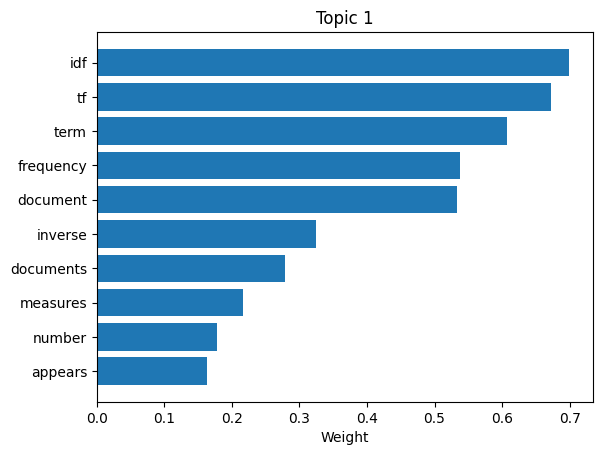

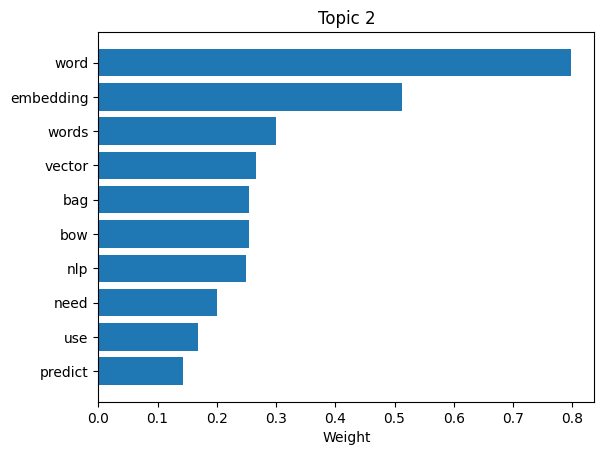

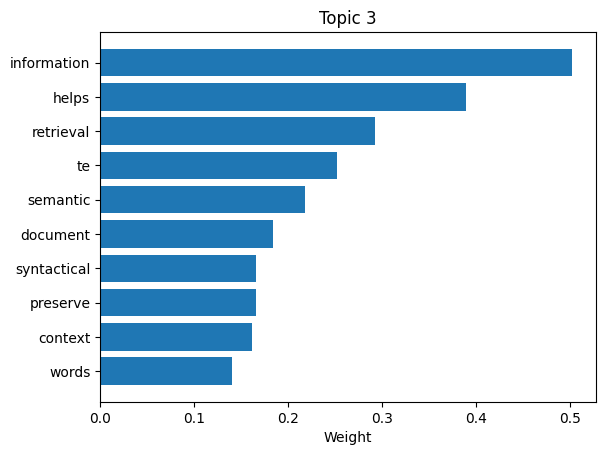

In [10]:
import matplotlib.pyplot as plt

def plot_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        plt.figure()
        plt.barh(top_features, weights)
        plt.title(f"Topic {topic_idx + 1}")
        plt.xlabel("Weight")
        plt.show()

plot_top_words(nmf_model, vectorizer.get_feature_names_out())

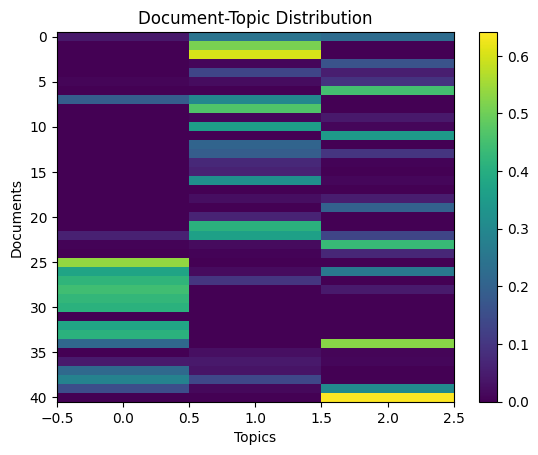

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(W, aspect='auto')
plt.colorbar()
plt.title("Document-Topic Distribution")
plt.xlabel("Topics")
plt.ylabel("Documents")
plt.show()

In [13]:
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 4.5 MB/s eta 0:00:00? eta -:--:--


###
WordCloud does not directly perform comparison; it visualizes word importance. Comparison is achieved by generating multiple word clouds and analyzing differences between them.”

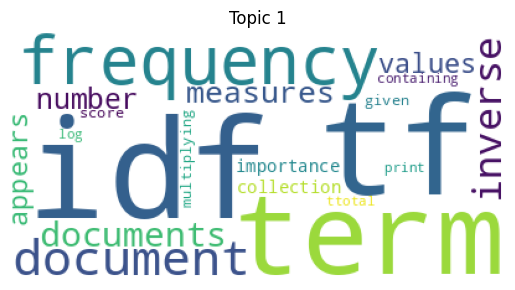

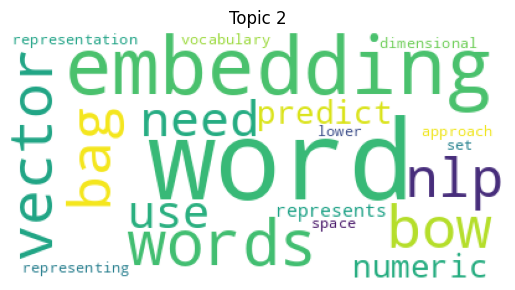

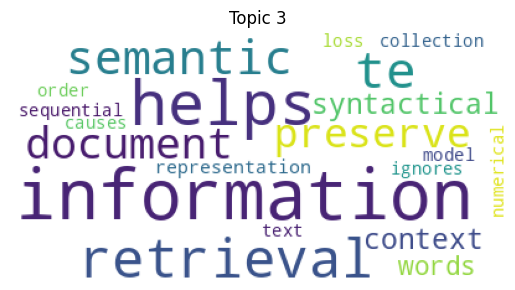

In [14]:
from wordcloud import WordCloud


for topic_idx, topic in enumerate(nmf_model.components_):
    word_freq = {vectorizer.get_feature_names_out()[i]: topic[i] for i in topic.argsort()[-20:]}
    
    wc = WordCloud(background_color='white')
    wc.generate_from_frequencies(word_freq)

    plt.figure()
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Topic {topic_idx+1}")
    plt.show()